## 1. Setup and Imports

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, deque
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# NLP and text processing
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD

# Machine learning models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Metrics and evaluation
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, classification_report,
                             confusion_matrix, roc_auc_score)
from sklearn.model_selection import train_test_split

# Dataset
from datasets import load_dataset

# Set random seed for reproducibility
np.random.seed(42)

# Download required NLTK data
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')

print("All libraries imported successfully!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


All libraries imported successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


## 2. Load AG News Dataset

In [ ]:
# Load AG News dataset from HuggingFace
print("Loading AG News dataset from HuggingFace...")
dataset = load_dataset("fancyzhx/ag_news")

# Convert to pandas DataFrames
train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

# Subsample with balanced class distribution
# Train: 9500 total, 2375 per class | Test: 3420 total, 855 per class
train_df = (train_df.groupby('label', group_keys=False)
            .apply(lambda x: x.sample(n=2375, random_state=42))
            .reset_index(drop=True))

test_df = (test_df.groupby('label', group_keys=False)
           .apply(lambda x: x.sample(n=855, random_state=42))
           .reset_index(drop=True))

# Define class labels
class_names = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
train_df['label_name'] = train_df['label'].map(class_names)
test_df['label_name'] = test_df['label'].map(class_names)

print(f"Dataset loaded successfully!")
print(f"\nTrain set size: {len(train_df):,}")
print(f"Test set size: {len(test_df):,}")
print(f"\nClass labels: {class_names}")
print("\nFirst few samples:")
train_df.head()

Loading AG News dataset from HuggingFace...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Dataset loaded successfully!

Train set size: 9,500
Test set size: 3,420

Class labels: {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}

First few samples:


,text,label,label_name
0,"BBC set for major shake-up, claims newspaper L...",2,Business
1,Marsh averts cash crunch Embattled insurance b...,2,Business
2,"Jeter, Yankees Look to Take Control (AP) AP - ...",1,Sports
3,Flying the Sun to Safety When the Genesis caps...,3,Sci/Tech
4,Stocks Seen Flat as Nortel and Oil Weigh NEW ...,2,Business


## 3. Exploratory Data Analysis (EDA)

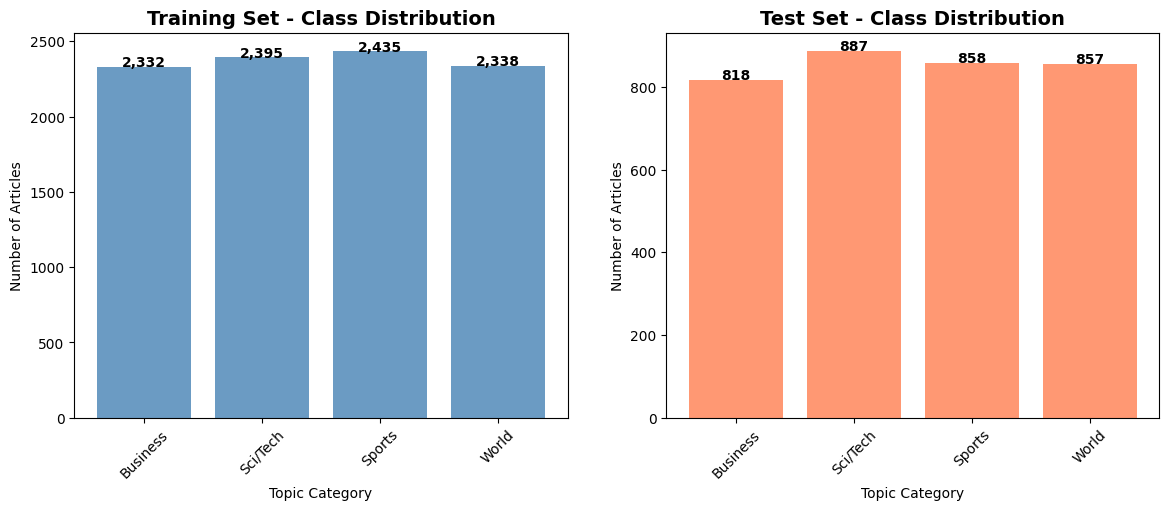

Class Distribution Statistics:

Training Set:
label_name
Business    2332
Sci/Tech    2395
Sports      2435
World       2338
Name: count, dtype: int64

Test Set:
label_name
Business    818
Sci/Tech    887
Sports      858
World       857
Name: count, dtype: int64


In [3]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train set distribution
train_counts = train_df['label_name'].value_counts().sort_index()
axes[0].bar(train_counts.index, train_counts.values, color='steelblue', alpha=0.8)
axes[0].set_title('Training Set - Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Topic Category')
axes[0].set_ylabel('Number of Articles')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v + 1, f'{v:,}', ha='center', fontweight='bold')

# Test set distribution
test_counts = test_df['label_name'].value_counts().sort_index()
axes[1].bar(test_counts.index, test_counts.values, color='coral', alpha=0.8)
axes[1].set_title('Test Set - Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Topic Category')
axes[1].set_ylabel('Number of Articles')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(test_counts.values):
    axes[1].text(i, v + 1, f'{v:,}', ha='center', fontweight='bold')

plt.show()

print("Class Distribution Statistics:")
print("\nTraining Set:")
print(train_df['label_name'].value_counts().sort_index())
print("\nTest Set:")
print(test_df['label_name'].value_counts().sort_index())

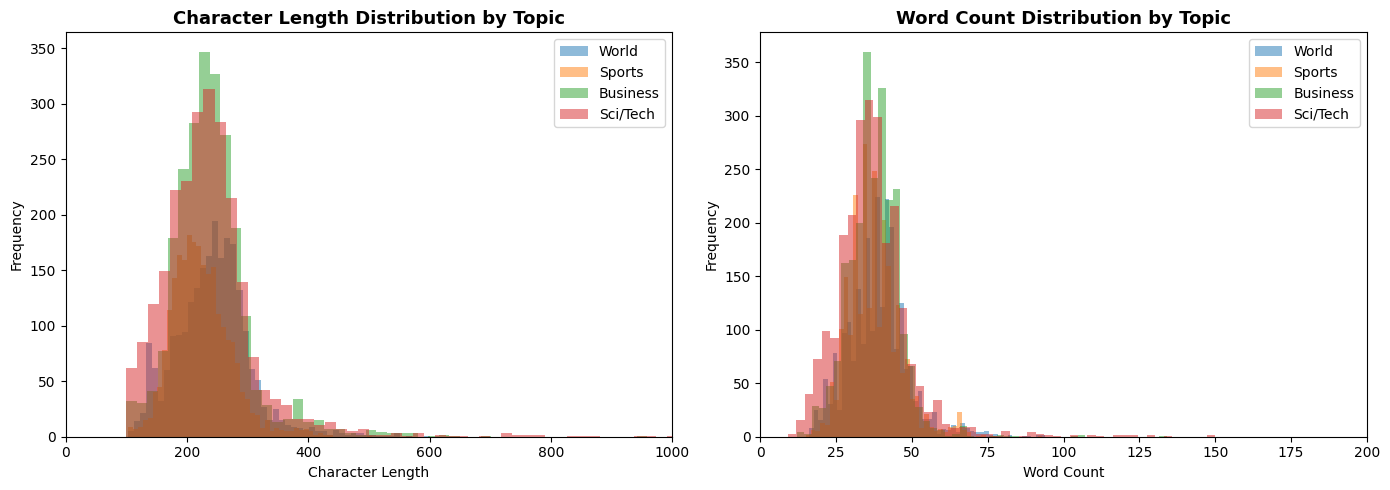


Text Statistics by Topic:
           text_length                                                     \
                 count    mean    std    min    25%    50%    75%     max   
label_name                                                                  
Business        2332.0  240.71  66.43  100.0  203.0  235.0  266.0   959.0   
Sci/Tech        2395.0  236.74  84.43  100.0  187.5  229.0  267.0  1009.0   
Sports          2435.0  223.89  49.07  103.0  190.0  219.0  251.0   505.0   
World           2338.0  243.06  62.60  102.0  204.0  243.0  276.0   601.0   

           word_count                                               
                count   mean    std   min   25%   50%   75%    max  
label_name                                                          
Business       2332.0  37.52   8.64  12.0  32.0  37.0  43.0  134.0  
Sci/Tech       2395.0  37.14  12.84   9.0  30.0  36.0  42.0  150.0  
Sports         2435.0  37.60   8.63  15.0  32.0  37.0  42.0   93.0  
World          2338

In [4]:
# Text length analysis
train_df['text_length'] = train_df['text'].str.len()
train_df['word_count'] = train_df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Character length distribution by class
for label_name in class_names.values():
    subset = train_df[train_df['label_name'] == label_name]
    axes[0].hist(subset['text_length'], bins=50, alpha=0.5, label=label_name)
axes[0].set_title('Character Length Distribution by Topic', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Character Length')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].set_xlim(0, 1000)

# Word count distribution by class
for label_name in class_names.values():
    subset = train_df[train_df['label_name'] == label_name]
    axes[1].hist(subset['word_count'], bins=50, alpha=0.5, label=label_name)
axes[1].set_title('Word Count Distribution by Topic', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].set_xlim(0, 200)

plt.tight_layout()
plt.show()

print("\nText Statistics by Topic:")
print(train_df.groupby('label_name')[['text_length', 'word_count']].describe().round(2))

## 4. Text Preprocessing (NLP)

In [5]:
import nltk
nltk.download('all')
# Initialize preprocessing tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """
    Comprehensive text preprocessing pipeline
    - Lowercase conversion
    - Remove special characters and numbers
    - Tokenization
    - Remove stopwords
    - Lemmatization
    """
    # Lowercase
    text = text.lower()

    # Remove special characters, keep only letters and spaces
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(token) for token in tokens
              if token not in stop_words and len(token) > 2]

    return ' '.join(tokens)

# Apply preprocessing
print("Preprocessing training data...")
train_df['text_clean'] = train_df['text'].apply(preprocess_text)

print("Preprocessing test data...")
test_df['text_clean'] = test_df['text'].apply(preprocess_text)

print("\nText preprocessing completed!")
print("\nExample of preprocessing:")
print(f"\nOriginal:\n{train_df.iloc[0]['text'][:200]}...")
print(f"\nCleaned:\n{train_df.iloc[0]['text_clean'][:200]}...")

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

Preprocessing training data...
Preprocessing test data...

Text preprocessing completed!

Example of preprocessing:

Original:
BBC set for major shake-up, claims newspaper London - The British Broadcasting Corporation, the world #39;s biggest public broadcaster, is to cut almost a quarter of its 28 000-strong workforce, in th...

Cleaned:
bbc set major shakeup claim newspaper london british broadcasting corporation world biggest public broadcaster cut almost quarter strong workforce biggest shakeup year history time newspaper london sa...


## 5. Feature Extraction: Converting Text to Numerical Data

In [6]:
# TF-IDF Vectorization
print("Extracting TF-IDF features...")

# Using TF-IDF with optimized parameters
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,      # Top 10k features
    ngram_range=(1, 2),      # Unigrams and bigrams
    min_df=2,                # Lowered to 2 for 9 500-sample subset
    max_df=0.8,              # Maximum document frequency
    sublinear_tf=True        # Apply sublinear tf scaling
)

# Fit on training data and transform both sets
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df['text_clean'])
X_test_tfidf = tfidf_vectorizer.transform(test_df['text_clean'])

# Extract labels
y_train = train_df['label'].values
y_test = test_df['label'].values

print(f"\nFeature extraction completed!")
print(f"Training features shape: {X_train_tfidf.shape}")
print(f"Test features shape: {X_test_tfidf.shape}")
print(f"Feature dimensionality: {X_train_tfidf.shape[1]:,} features")
print(f"Sparsity: {(1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])) * 100:.2f}%")

Extracting TF-IDF features...

Feature extraction completed!
Training features shape: (9500, 10000)
Test features shape: (3420, 10000)
Feature dimensionality: 10,000 features
Sparsity: 99.78%


## 6. Baseline Classification Models

In [7]:
# Define multiple classifiers for comparison
classifiers = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Linear SVM': LinearSVC(max_iter=1000, random_state=42),
    'SGD Classifier': SGDClassifier(max_iter=1000, random_state=42)
}

# Train and evaluate each classifier
baseline_results = {}

print("Training baseline classifiers...\n")

for name, clf in classifiers.items():
    print(f"\n{name}")

    # Train
    clf.fit(X_train_tfidf, y_train)

    # Predict
    y_pred = clf.predict(X_test_tfidf)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')

    # Store results
    baseline_results[name] = {
        'model': clf,
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'precision': precision,
        'recall': recall,
        'predictions': y_pred
    }

    print(f"Accuracy:          {accuracy:.4f}")
    print(f"F1 (Macro):        {f1_macro:.4f}")
    print(f"F1 (Weighted):     {f1_weighted:.4f}")
    print(f"Precision:         {precision:.4f}")
    print(f"Recall:            {recall:.4f}")

Training baseline classifiers...


Naive Bayes
Accuracy:          0.8889
F1 (Macro):        0.8882
F1 (Weighted):     0.8885
Precision:         0.8885
Recall:            0.8889

Logistic Regression
Accuracy:          0.8915
F1 (Macro):        0.8909
F1 (Weighted):     0.8912
Precision:         0.8912
Recall:            0.8915

Linear SVM
Accuracy:          0.8924
F1 (Macro):        0.8918
F1 (Weighted):     0.8921
Precision:         0.8920
Recall:            0.8924

SGD Classifier
Accuracy:          0.8953
F1 (Macro):        0.8946
F1 (Weighted):     0.8949
Precision:         0.8948
Recall:            0.8953


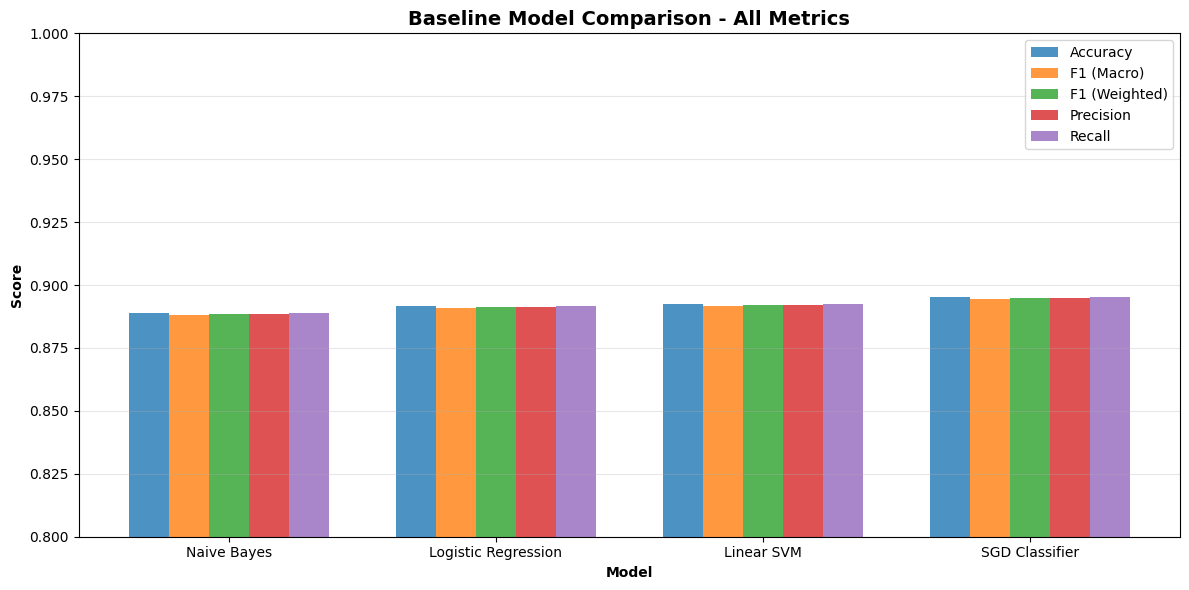

In [8]:
# Visualize baseline results
results_df = pd.DataFrame({
    'Model': list(baseline_results.keys()),
    'Accuracy': [v['accuracy'] for v in baseline_results.values()],
    'F1 (Macro)': [v['f1_macro'] for v in baseline_results.values()],
    'F1 (Weighted)': [v['f1_weighted'] for v in baseline_results.values()],
    'Precision': [v['precision'] for v in baseline_results.values()],
    'Recall': [v['recall'] for v in baseline_results.values()]
})

# Create comparison plot with a single subplot
fig, ax = plt.subplots(figsize=(12, 6))

# Bar chart of all metrics
x = np.arange(len(results_df))
width = 0.15
metrics = ['Accuracy', 'F1 (Macro)', 'F1 (Weighted)', 'Precision', 'Recall']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, metric in enumerate(metrics):
    ax.bar(x + i*width, results_df[metric], width, label=metric, color=colors[i], alpha=0.8)

ax.set_xlabel('Model', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Baseline Model Comparison - All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df['Model'], rotation=0, ha='center')
ax.legend()
ax.set_ylim(0.8, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Best Baseline Model: SGD Classifier
Accuracy: 0.8953


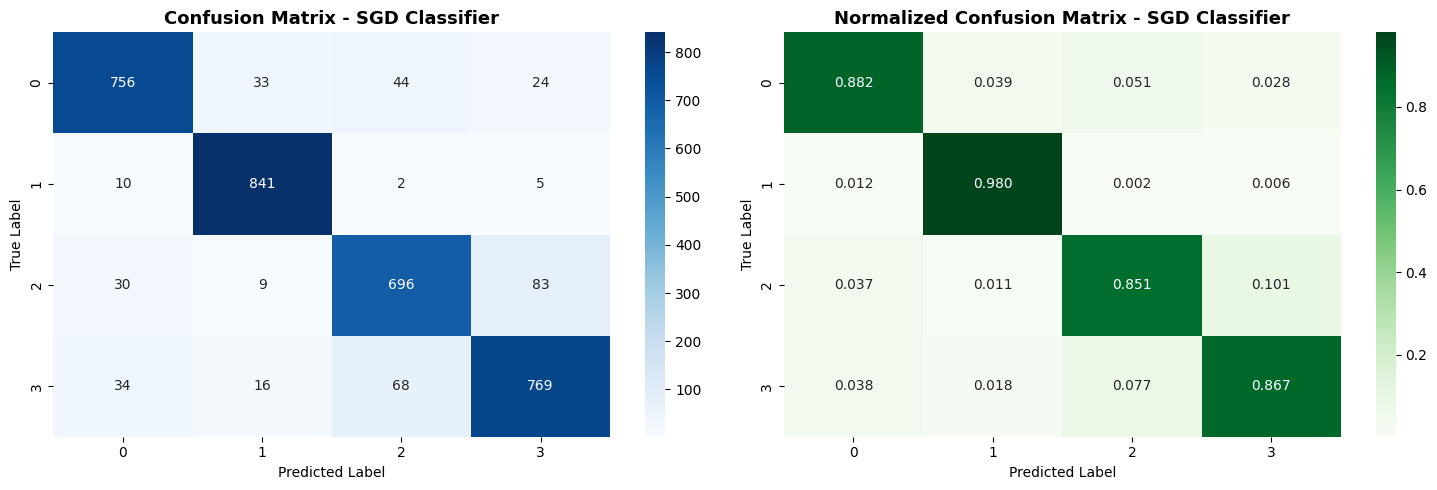


Detailed Classification Report - SGD Classifier:
              precision    recall  f1-score   support

       World       0.91      0.88      0.90       857
      Sports       0.94      0.98      0.96       858
    Business       0.86      0.85      0.86       818
    Sci/Tech       0.87      0.87      0.87       887

    accuracy                           0.90      3420
   macro avg       0.89      0.90      0.89      3420
weighted avg       0.89      0.90      0.89      3420



In [9]:
# Select best model for streaming evaluation
best_model_name = max(baseline_results.keys(), key=lambda k: baseline_results[k]['accuracy'])
best_model = baseline_results[best_model_name]['model']
best_predictions = baseline_results[best_model_name]['predictions']

print(f"Best Baseline Model: {best_model_name}")
print(f"Accuracy: {baseline_results[best_model_name]['accuracy']:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, best_predictions)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            ax=axes[0])
axes[0].set_title(f'Confusion Matrix - {best_model_name}', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Greens',
            ax=axes[1])
axes[1].set_title(f'Normalized Confusion Matrix - {best_model_name}', fontsize=13, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Detailed classification report
print(f"\nDetailed Classification Report - {best_model_name}:")
print(classification_report(y_test, best_predictions, target_names=class_names.values()))

# Drift Detection Algorithms Implementation

In [10]:
class DriftDetector:
    """Base class for drift detection"""
    def __init__(self, name):
        self.name = name
        self.drift_detected = False
        self.warning_detected = False

    def update(self, error):
        """Update detector with new error observation"""
        raise NotImplementedError

    def reset(self):
        """Reset detector state"""
        raise NotImplementedError


class DDM(DriftDetector):
    """
    Drift Detection Method (DDM)
    Monitors error rate and its standard deviation
    """
    def __init__(self, min_instances=30, warning_level=2.0, drift_level=3.0):
        super().__init__("DDM")
        self.min_instances = min_instances
        self.warning_level = warning_level
        self.drift_level = drift_level
        self.reset()

    def reset(self):
        self.n = 0
        self.p_min = float('inf')
        self.s_min = float('inf')
        self.p = 1.0
        self.s = 0.0
        self.drift_detected = False
        self.warning_detected = False

    def update(self, error):
        self.n += 1
        self.p += (error - self.p) / self.n
        self.s = np.sqrt(self.p * (1 - self.p) / self.n)

        self.drift_detected = False
        self.warning_detected = False

        if self.n > self.min_instances:
            if self.p + self.s < self.p_min + self.s_min:
                self.p_min = self.p
                self.s_min = self.s

            threshold_warning = self.p_min + self.warning_level * self.s_min
            threshold_drift = self.p_min + self.drift_level * self.s_min

            if self.p + self.s >= threshold_drift:
                self.drift_detected = True
            elif self.p + self.s >= threshold_warning:
                self.warning_detected = True


class EDDM(DriftDetector):
    """
    Early Drift Detection Method (EDDM)
    Monitors distance between errors
    """
    def __init__(self, min_instances=30, warning_level=0.95, drift_level=0.9):
        super().__init__("EDDM")
        self.min_instances = min_instances
        self.warning_level = warning_level
        self.drift_level = drift_level
        self.reset()

    def reset(self):
        self.n = 0
        self.n_errors = 0
        self.last_error_pos = 0
        self.distance_sum = 0.0
        self.distance_sq_sum = 0.0
        self.mean_max = 0.0
        self.std_max = 0.0
        self.drift_detected = False
        self.warning_detected = False

    def update(self, error):
        self.n += 1
        self.drift_detected = False
        self.warning_detected = False

        if error:
            distance = self.n - self.last_error_pos
            self.last_error_pos = self.n
            self.n_errors += 1
            self.distance_sum += distance
            self.distance_sq_sum += distance * distance

            if self.n_errors >= self.min_instances:
                mean = self.distance_sum / self.n_errors
                std = np.sqrt(self.distance_sq_sum / self.n_errors - mean * mean)

                if mean + 2 * std > self.mean_max + 2 * self.std_max:
                    self.mean_max = mean
                    self.std_max = std

                if self.mean_max + 2 * self.std_max > 0:
                    ratio = (mean + 2 * std) / (self.mean_max + 2 * self.std_max)

                    if ratio < self.drift_level:
                        self.drift_detected = True
                    elif ratio < self.warning_level:
                        self.warning_detected = True


class ADWIN(DriftDetector):
    """
    Adaptive Windowing (ADWIN)
    Maintains adaptive-size sliding window
    """
    def __init__(self, delta=0.002):
        super().__init__("ADWIN")
        self.delta = delta
        self.reset()

    def reset(self):
        self.window = deque()
        self.total = 0.0
        self.variance = 0.0
        self.width = 0
        self.drift_detected = False
        self.warning_detected = False

    def update(self, error):
        self.drift_detected = False
        self.window.append(error)
        self.width += 1

        if self.width > 1:
            # Check for drift
            n0 = self.width // 2
            n1 = self.width - n0

            sum0 = sum(list(self.window)[:n0])
            sum1 = sum(list(self.window)[n0:])

            mean0 = sum0 / n0
            mean1 = sum1 / n1

            diff = abs(mean0 - mean1)

            # Simplified drift threshold
            m = 1 / (1/n0 + 1/n1)
            epsilon = np.sqrt(2 * np.log(2 / self.delta) / m)

            if diff > epsilon:
                self.drift_detected = True
                # Remove oldest half of window
                for _ in range(n0):
                    self.window.popleft()
                self.width = len(self.window)


class PageHinkley(DriftDetector):
    """
    Page-Hinkley Test
    Detects changes in the mean of a signal
    """
    def __init__(self, min_instances=30, delta=0.005, threshold=50, alpha=0.9999):
        super().__init__("Page-Hinkley")
        self.min_instances = min_instances
        self.delta = delta
        self.threshold = threshold
        self.alpha = alpha
        self.reset()

    def reset(self):
        self.n = 0
        self.sum = 0.0
        self.x_mean = 0.0
        self.PH = 0.0
        self.min_PH = float('inf')
        self.drift_detected = False
        self.warning_detected = False

    def update(self, error):
        self.n += 1
        self.drift_detected = False

        # Update mean
        self.x_mean += (error - self.x_mean) / self.n

        # Update PH statistic
        self.PH += error - self.x_mean - self.delta

        if self.PH < self.min_PH:
            self.min_PH = self.PH

        # Check for drift
        if self.n > self.min_instances:
            if self.PH - self.min_PH > self.threshold:
                self.drift_detected = True
                self.reset()

print("Drift detection algorithms implemented!")
print(f"  - DDM (Drift Detection Method)")
print(f"  - EDDM (Early Drift Detection Method)")
print(f"  - ADWIN (Adaptive Windowing)")
print(f"  - Page-Hinkley Test")

Drift detection algorithms implemented!
  - DDM (Drift Detection Method)
  - EDDM (Early Drift Detection Method)
  - ADWIN (Adaptive Windowing)
  - Page-Hinkley Test


# Simulating Real-Time News Stream with Concept Drift

Injecting concept drift into test stream...
  Stream length  : 3420
  Drift points   : [600, 1500, 2400]
  Drift magnitude: 0.4

  Drift 1 (idx 600): Label shift – Increase Sports prevalence
  Drift 2 (idx 1500): Class confusion – World ↔ Business
  Drift 3 (idx 2400): Label noise – random misclassification

Drift injection completed!


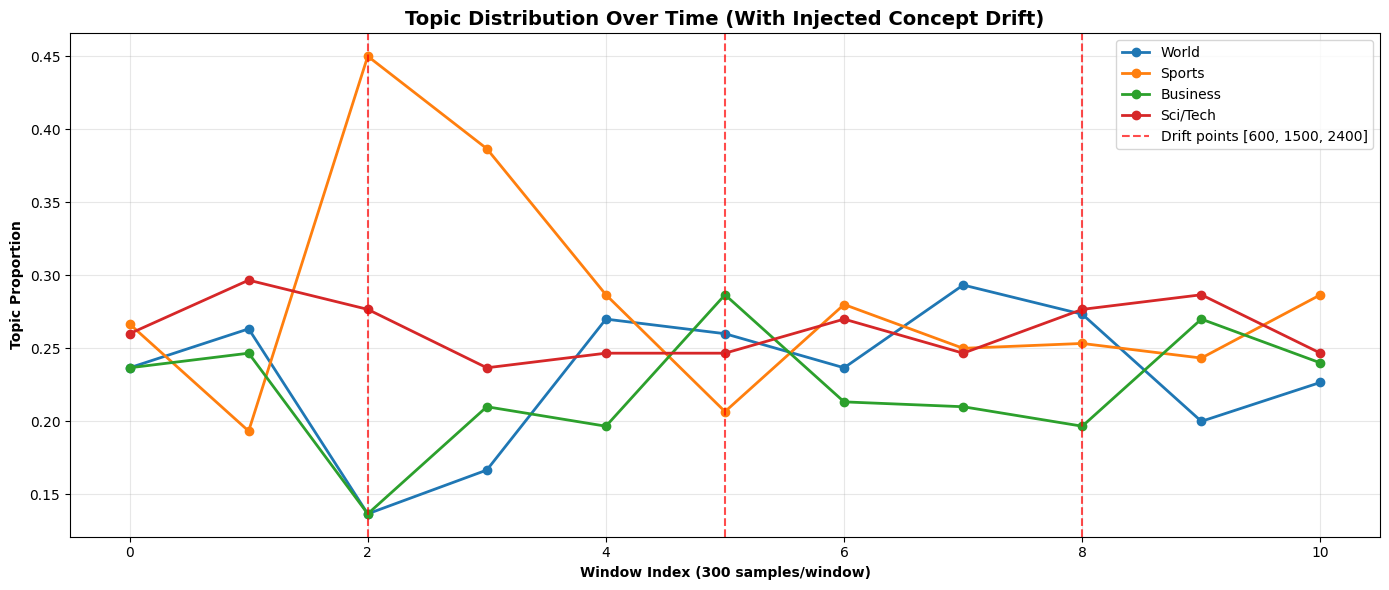

In [11]:
def create_drifted_stream(test_df, drift_points, drift_magnitude=0.4):
    """
    Inject three types of concept drift into the ordered test stream.

    Drift types:
      1. Label shift     – artificially increases Sports prevalence
      2. Class confusion – swaps World ↔ Business labels
      3. Label noise     – random misclassification

    Parameters
    ----------
    test_df         : DataFrame with columns 'text_clean' and 'label'
    drift_points    : list of starting sample indices for each drift episode
    drift_magnitude : fraction of affected samples (0–1)
    """
    df = test_df.copy().reset_index(drop=True)
    n = len(df)

    print("Injecting concept drift into test stream...")
    print(f"  Stream length  : {n}")
    print(f"  Drift points   : {drift_points}")
    print(f"  Drift magnitude: {drift_magnitude}\n")

    for i, drift_idx in enumerate(drift_points):
        if drift_idx >= n:
            print(f"  [SKIP] Drift {i+1} at {drift_idx} exceeds stream length {n}")
            continue

        start_idx = drift_idx
        end_idx   = min(drift_idx + 500, n - 1)

        if i == 0:
            # Drift 1: Label shift – inflate Sports
            print(f"  Drift 1 (idx {drift_idx}): Label shift – Increase Sports prevalence")
            mask  = df.loc[start_idx:end_idx, 'label'].isin([0, 2])
            swap  = df.loc[start_idx:end_idx][mask].sample(frac=drift_magnitude,
                                                            random_state=1).index
            df.loc[swap, 'label'] = 1

        elif i == 1:
            # Drift 2: Class confusion – swap World ↔ Business
            print(f"  Drift 2 (idx {drift_idx}): Class confusion – World ↔ Business")
            w_idx = df.loc[start_idx:end_idx][df.loc[start_idx:end_idx, 'label'] == 0]\
                      .sample(frac=drift_magnitude, random_state=2).index
            b_idx = df.loc[start_idx:end_idx][df.loc[start_idx:end_idx, 'label'] == 2]\
                      .sample(frac=drift_magnitude, random_state=3).index
            df.loc[w_idx, 'label'] = 2
            df.loc[b_idx, 'label'] = 0

        elif i == 2:
            # Drift 3: Label noise – random misclassification
            print(f"  Drift 3 (idx {drift_idx}): Label noise – random misclassification")
            noise_idx = df.loc[start_idx:end_idx].sample(frac=drift_magnitude,
                                                          random_state=4).index
            for ix in noise_idx:
                orig = df.at[ix, 'label']
                df.at[ix, 'label'] = np.random.choice([l for l in range(4) if l != orig])

    df['label_name'] = df['label'].map(class_names)
    print("\nDrift injection completed!")
    return df

# Drift points scaled to fit the 3 420-sample test set
# Each window covers 500 samples; last window: 2400+500=2900 < 3420
STREAM_DRIFT_POINTS = [600, 1500, 2400]

drifted_test_df = create_drifted_stream(test_df,
                                        drift_points=STREAM_DRIFT_POINTS,
                                        drift_magnitude=0.4)

# Visualise topic distribution over the stream
WINDOW_VIZ = 300          # 3420 // 300 = 11 windows
num_windows = len(drifted_test_df) // WINDOW_VIZ

topic_dist_over_time = []
for i in range(num_windows):
    chunk = drifted_test_df.iloc[i * WINDOW_VIZ:(i + 1) * WINDOW_VIZ]
    dist  = chunk['label'].value_counts(normalize=True).reindex(range(4), fill_value=0)
    topic_dist_over_time.append(dist.values)

topic_dist_array = np.array(topic_dist_over_time)

fig, ax = plt.subplots(figsize=(14, 6))
for j, topic in enumerate(class_names.values()):
    ax.plot(range(num_windows), topic_dist_array[:, j],
            marker='o', label=topic, linewidth=2)

# Drift vlines — one legend proxy for all three
for dp in STREAM_DRIFT_POINTS:
    ax.axvline(x=dp / WINDOW_VIZ, color='red', linestyle='--', alpha=0.7)
ax.plot([], [], color='red', linestyle='--', alpha=0.7,
        label=f'Drift points {STREAM_DRIFT_POINTS}')

ax.set_xlabel(f'Window Index ({WINDOW_VIZ} samples/window)', fontweight='bold')
ax.set_ylabel('Topic Proportion', fontweight='bold')
ax.set_title('Topic Distribution Over Time (With Injected Concept Drift)',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Online Evaluation with Prequential Metrics

In [12]:
def prequential_evaluation_with_drift_detection(
    model,
    test_df,
    vectorizer,
    detector,
    window_size=100,
    retrain_on_drift=True
):
    """
    Prequential (test-then-train) evaluation with drift detection

    Args:
        model: Trained classifier
        test_df: Test DataFrame with 'text_clean' and 'label'
        vectorizer: Fitted TF-IDF vectorizer
        detector: Drift detector instance
        window_size: Window size for moving metrics
        retrain_on_drift: Whether to retrain model upon drift detection

    Returns:
        Dictionary with evaluation metrics and drift information
    """
    # Initialize tracking variables
    n_samples = len(test_df)
    predictions = []
    true_labels = []
    errors = []
    accuracies = []
    drift_points = []
    warning_points = []

    # Moving window for metrics
    window_correct = deque(maxlen=window_size)

    # Make a copy of the model for online learning
    online_model = model

    print(f"Starting prequential evaluation with {detector.name}...")
    print(f"Stream length: {n_samples}, Window size: {window_size}")

    # Process stream sample by sample
    for i in range(n_samples):
        # Get current sample
        X_text = test_df.iloc[i]['text_clean']
        y_true = test_df.iloc[i]['label']

        # Transform to features
        X_vec = vectorizer.transform([X_text])

        # Predict (TEST phase)
        y_pred = online_model.predict(X_vec)[0]

        # Record results
        predictions.append(y_pred)
        true_labels.append(y_true)

        # Calculate error
        error = 1 if y_pred != y_true else 0
        errors.append(error)
        window_correct.append(1 - error)

        # Update drift detector
        detector.update(error)

        # Record drift/warning
        if detector.drift_detected:
            drift_points.append(i)
            if retrain_on_drift:
                # Retrain model on recent data
                start_retrain = max(0, i - 1000)
                retrain_data = test_df.iloc[start_retrain:i]
                X_retrain = vectorizer.transform(retrain_data['text_clean'])
                y_retrain = retrain_data['label'].values

                # Clone and retrain
                from sklearn.base import clone
                online_model = clone(model)
                online_model.fit(X_retrain, y_retrain)
                detector.reset()

        if detector.warning_detected:
            warning_points.append(i)

        # Calculate moving accuracy
        if len(window_correct) == window_size:
            accuracies.append(np.mean(window_correct))
        else:
            accuracies.append(np.mean(window_correct) if window_correct else 0.0)

        # Progress reporting
        if (i + 1) % 1000 == 0:
            current_acc = accuracies[-1] if accuracies else 0.0
            n_drifts = len(drift_points)
            print(f"Sample {i+1:5d}/{n_samples} | "
                  f"Moving Acc: {current_acc:.4f} | "
                  f"Drifts Detected: {n_drifts}")

    # Calculate final metrics
    final_accuracy = accuracy_score(true_labels, predictions)
    final_f1 = f1_score(true_labels, predictions, average='weighted')

    print(f"Evaluation completed!")
    print(f"Final Accuracy: {final_accuracy:.4f}")
    print(f"Final F1 Score: {final_f1:.4f}")
    print(f"Total Drifts Detected: {len(drift_points)}")
    print(f"Total Warnings: {len(warning_points)}")

    return {
        'detector_name': detector.name,
        'predictions': predictions,
        'true_labels': true_labels,
        'errors': errors,
        'accuracies': accuracies,
        'drift_points': drift_points,
        'warning_points': warning_points,
        'final_accuracy': final_accuracy,
        'final_f1': final_f1,
        'retrain_on_drift': retrain_on_drift
    }

print("Prequential evaluation function defined!")

Prequential evaluation function defined!


# Compare Drift Detection Methods

In [13]:
# Initialize drift detectors
detectors = {
    'DDM': DDM(min_instances=30, warning_level=2.0, drift_level=3.0),
    'EDDM': EDDM(min_instances=30, warning_level=0.95, drift_level=0.9),
    'ADWIN': ADWIN(delta=0.002),
    'Page-Hinkley': PageHinkley(min_instances=30, delta=0.005, threshold=50)
}

# Run evaluation for each detector
results_all_detectors = {}

print("Running prequential evaluation with all drift detectors...")
print("This may take a few minutes...\n")

for detector_name, detector in detectors.items():
    print(f"# Evaluating with {detector_name}")

    # Run evaluation
    result = prequential_evaluation_with_drift_detection(
        model=best_model,
        test_df=drifted_test_df,
        vectorizer=tfidf_vectorizer,
        detector=detector,
        window_size=100,
        retrain_on_drift=True
    )

    results_all_detectors[detector_name] = result
    print()

print("All evaluations completed!")

Running prequential evaluation with all drift detectors...
This may take a few minutes...

# Evaluating with DDM
Starting prequential evaluation with DDM...
Stream length: 3420, Window size: 100
Sample  1000/3420 | Moving Acc: 0.6300 | Drifts Detected: 3
Sample  2000/3420 | Moving Acc: 0.7200 | Drifts Detected: 3
Sample  3000/3420 | Moving Acc: 0.6900 | Drifts Detected: 4
Evaluation completed!
Final Accuracy: 0.6515
Final F1 Score: 0.6491
Total Drifts Detected: 4
Total Warnings: 1136

# Evaluating with EDDM
Starting prequential evaluation with EDDM...
Stream length: 3420, Window size: 100
Sample  1000/3420 | Moving Acc: 0.6400 | Drifts Detected: 2
Sample  2000/3420 | Moving Acc: 0.7400 | Drifts Detected: 2
Sample  3000/3420 | Moving Acc: 0.7200 | Drifts Detected: 4
Evaluation completed!
Final Accuracy: 0.7158
Final F1 Score: 0.7149
Total Drifts Detected: 4
Total Warnings: 312

# Evaluating with ADWIN
Starting prequential evaluation with ADWIN...
Stream length: 3420, Window size: 100
Sa

# Visualization and Performance Comparison

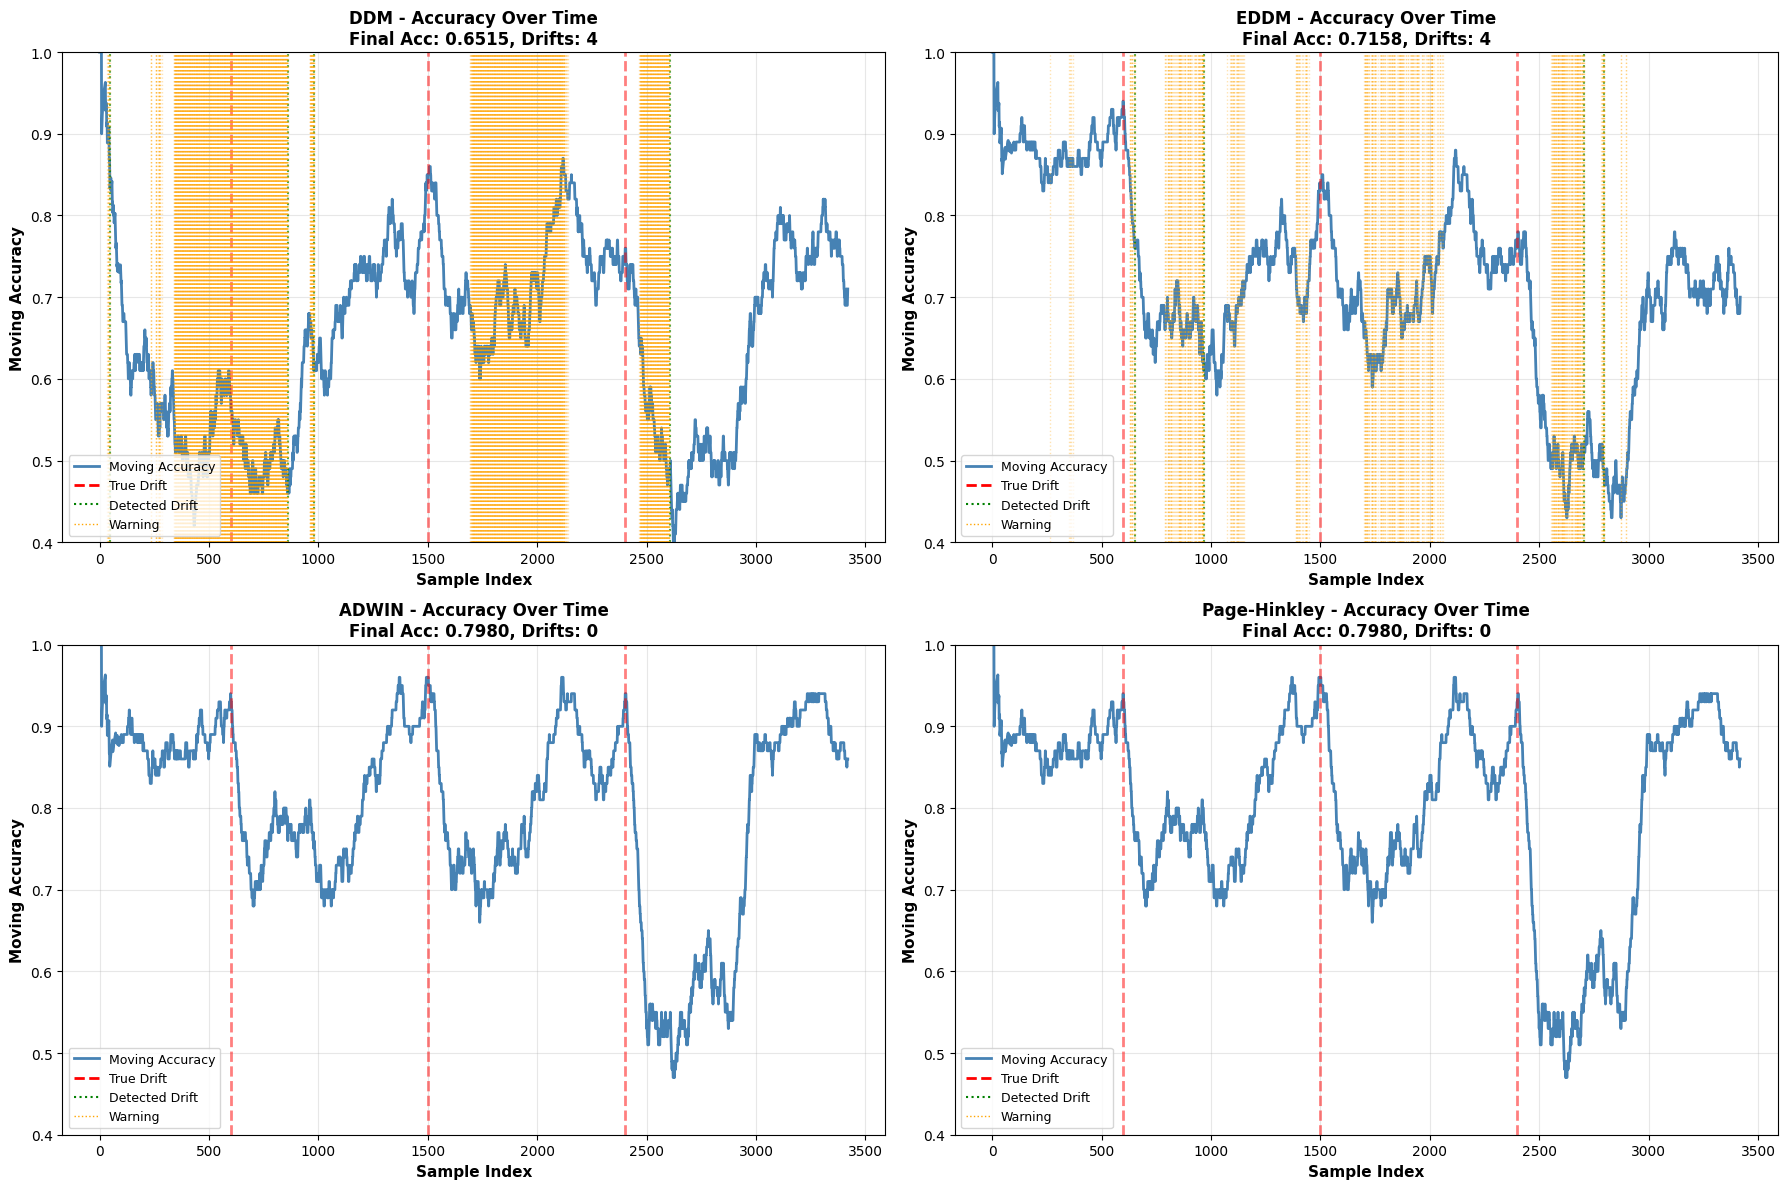

In [14]:
# Plot accuracy over time with drift points for all detectors
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

# True drift points aligned with the scaled stream
true_drift_points = STREAM_DRIFT_POINTS  # [600, 1500, 2400]

for idx, (detector_name, result) in enumerate(results_all_detectors.items()):
    ax = axes[idx]

    # Plot moving accuracy
    ax.plot(range(len(result['accuracies'])), result['accuracies'],
            label='Moving Accuracy (window=100)', linewidth=2, color='steelblue')

    # Plot true drift points
    for drift_pt in true_drift_points:
        ax.axvline(x=drift_pt, color='red', linestyle='--', alpha=0.5, linewidth=2)

    # Plot detected drift points
    for drift_pt in result['drift_points']:
        ax.axvline(x=drift_pt, color='green', linestyle=':', alpha=0.7, linewidth=1.5)

    # Plot warning points (if any)
    if result['warning_points']:
        for warn_pt in result['warning_points']:
            ax.axvline(x=warn_pt, color='orange', linestyle=':', alpha=0.3, linewidth=1)

    ax.set_xlabel('Sample Index', fontweight='bold', fontsize=11)
    ax.set_ylabel('Moving Accuracy', fontweight='bold', fontsize=11)
    ax.set_title(f'{detector_name} - Accuracy Over Time\nFinal Acc: {result["final_accuracy"]:.4f}, Drifts: {len(result["drift_points"])}',
                fontweight='bold', fontsize=12)
    ax.set_ylim(0.4, 1.0)  # Wider range to capture accuracy drops during drift
    ax.grid(alpha=0.3)

    # Create custom legend
    from matplotlib.lines import Line2D
    custom_lines = [
        Line2D([0], [0], color='steelblue', lw=2),
        Line2D([0], [0], color='red', linestyle='--', lw=2),
        Line2D([0], [0], color='green', linestyle=':', lw=1.5),
        Line2D([0], [0], color='orange', linestyle=':', lw=1)
    ]
    ax.legend(custom_lines, ['Moving Accuracy', 'True Drift', 'Detected Drift', 'Warning'],
             loc='lower left', fontsize=9)

plt.tight_layout()
plt.show()

In [15]:
# Drift Detection Performance Comparison
def evaluate_drift_detection_performance(detected_drifts, true_drifts, tolerance=200):
    """
    Evaluate drift detection performance

    Args:
        detected_drifts: List of detected drift positions
        true_drifts: List of true drift positions
        tolerance: Tolerance window for matching (samples)

    Returns:
        Dictionary with performance metrics
    """
    true_positives = 0
    delays = []

    for true_drift in true_drifts:
        # Check if any detected drift is within tolerance
        matches = [d for d in detected_drifts if abs(d - true_drift) <= tolerance]
        if matches:
            true_positives += 1
            # Calculate delay (use earliest detection)
            earliest = min(matches, key=lambda x: abs(x - true_drift))
            delays.append(abs(earliest - true_drift))

    false_positives = len(detected_drifts) - true_positives
    false_negatives = len(true_drifts) - true_positives

    precision = true_positives / len(detected_drifts) if detected_drifts else 0
    recall = true_positives / len(true_drifts) if true_drifts else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    avg_delay = np.mean(delays) if delays else np.nan

    return {
        'true_positives': true_positives,
        'false_positives': false_positives,
        'false_negatives': false_negatives,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'avg_detection_delay': avg_delay
    }

# Evaluate all detectors
comparison_data = []

for detector_name, result in results_all_detectors.items():
    drift_metrics = evaluate_drift_detection_performance(
        result['drift_points'],
        true_drift_points,
        tolerance=200
    )

    comparison_data.append({
        'Detector': detector_name,
        'Final Accuracy': result['final_accuracy'],
        'Final F1': result['final_f1'],
        'Drifts Detected': len(result['drift_points']),
        'True Positives': drift_metrics['true_positives'],
        'False Positives': drift_metrics['false_positives'],
        'False Negatives': drift_metrics['false_negatives'],
        'Detection Precision': drift_metrics['precision'],
        'Detection Recall': drift_metrics['recall'],
        'Detection F1': drift_metrics['f1_score'],
        'Avg Delay (samples)': drift_metrics['avg_detection_delay']
    })

comparison_df = pd.DataFrame(comparison_data)

# Display table
print("DRIFT DETECTION METHODS COMPARISON")
print(f"\nTrue drift points: {true_drift_points}")
print(f"Tolerance window: ±200 samples\n")
print(comparison_df.to_string(index=False))

DRIFT DETECTION METHODS COMPARISON

True drift points: [600, 1500, 2400]
Tolerance window: ±200 samples

    Detector  Final Accuracy  Final F1  Drifts Detected  True Positives  False Positives  False Negatives  Detection Precision  Detection Recall  Detection F1  Avg Delay (samples)
         DDM        0.651462  0.649056                4               0                4                3                 0.00          0.000000      0.000000                  NaN
        EDDM        0.715789  0.714857                4               1                3                2                 0.25          0.333333      0.285714                 53.0
       ADWIN        0.797953  0.799140                0               0                0                3                 0.00          0.000000      0.000000                  NaN
Page-Hinkley        0.797953  0.799140                0               0                0                3                 0.00          0.000000      0.000000                 